In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import sys
from pathlib import Path  
import numpy as np
import torch
import cv2
from PIL import Image
import random
# project_root = Path.cwd().parent  
# # sys.path.append(str(project_root))
# os.chdir(project_root)
sys.path.append('/mnt/bn/ocr-doc-nas/zhuhanshen/iccv/FreeFine')# Replace with your path
os.chdir('/mnt/bn/ocr-doc-nas/zhuhanshen/iccv/FreeFine')# Replace with your path
print(f"当前工作目录: {os.getcwd()}")
assert os.getcwd().split('/')[-1] == 'FreeFine', "Current working directory is not FreeFine"
from src.demo.model import FreeFinePipeline
from src.utils.attention import register_attention_control,Attention_Modulator,register_attention_control_4bggen
from src.utils.vis_utils import temp_view,temp_view_img,load_json,get_constrain_areas,prepare_mask_pool,re_edit_2d,dilate_mask,read_and_resize_mask,re_edit_3d,read_and_resize_img,read_and_resize_mask_from_pil,read_and_resize_img_from_pil

from diffusers import DDIMScheduler
from datasets import load_dataset
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
pretrained_model_path = "/mnt/bn/ocr-doc-nas/zhuhanshen/models/stable-diffusion-v1-5" #Replace with your own ckpt path
model = FreeFinePipeline.from_pretrained(pretrained_model_path, torch_dtype=torch.float16).to(device)
model.scheduler = DDIMScheduler.from_config(model.scheduler.config,)

当前工作目录: /mnt/bn/ocr-doc-nas/zhuhanshen/iccv/FreeFine


/mnt/bn/ocr-doc-nas/zhuhanshen/home/anaconda3/envs/FreeFine/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.


## 2D Editing 


In [9]:
edit_type = '2D'
if edit_type == '2D':
    dataset_2d = load_dataset("CIawevy/GeoBench", "2d")['data']  

Using the latest cached version of the dataset since CIawevy/GeoBench couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration '2d' at /home/tiger/.cache/huggingface/datasets/CIawevy___geo_bench/2d/0.0.0/8cd820a278f53ad2484edb8ee15b254023981b0b (last modified on Sun Aug 24 19:23:59 2025).


current sample is ID:4865


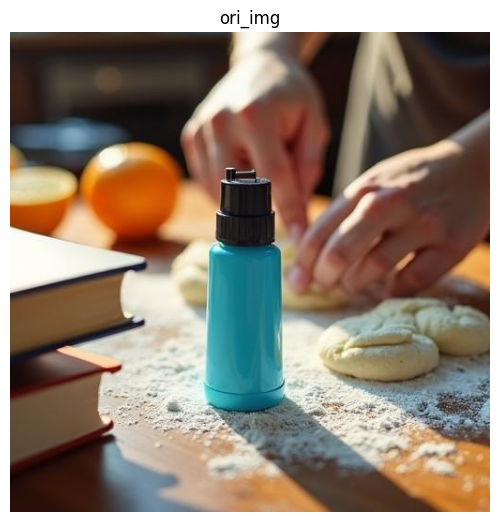

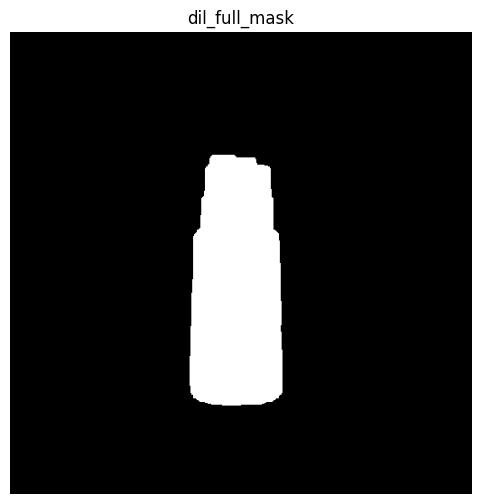

In [10]:
edit_type = '2D'
if edit_type == '2D':
    #debug ID=4865
    id = random.choice(range(len(dataset_2d)))
    id = 4865
    print(f'current sample is ID:{id}')
    sample = dataset_2d[id] 
    edit_param = sample['edit_param']
    ori_img = read_and_resize_img_from_pil(sample['ori_img'])
    coarse_input = read_and_resize_img_from_pil(sample['coarse_input'])
    ori_mask = read_and_resize_mask_from_pil(sample['ori_mask'])
    tgt_mask = read_and_resize_mask_from_pil(sample['tgt_mask'])
    obj_label = sample['obj_label']

constrain_areas = get_constrain_areas(mask_list=[ori_mask],ori_mask=ori_mask) #for practice use you can upload mask list with all the object mask to avoid dilation on other objects
dilation_factor = 20
dil_ori_mask = dilate_mask(ori_mask, dilation_factor)
dil_ori_mask = np.where(constrain_areas,0,dil_ori_mask)


temp_view_img(ori_img,'ori_img')
temp_view(dil_ori_mask,'dil_full_mask')


/mnt/bn/ocr-doc-nas/zhuhanshen/home/anaconda3/envs/FreeFine/lib/python3.10/site-packages/lightning_fabric/utilities/seed.py:51: 4733927130153262 is not in bounds, numpy accepts from 0 to 4294967295
Seed set to 928214438
DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:10<00:00,  4.77it/s]


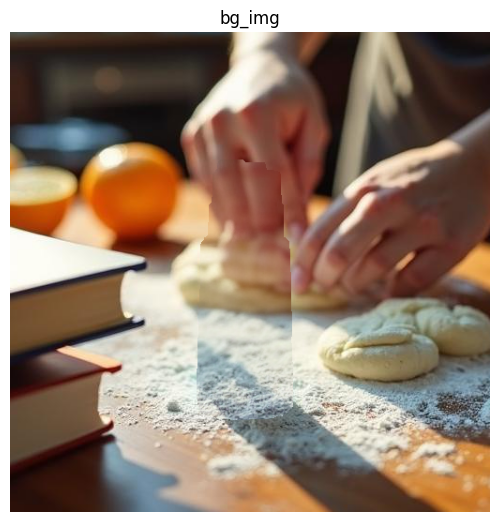

In [4]:
"""
Step1:Background Generation
"""
controller = Attention_Modulator()
model.controller = controller
register_attention_control_4bggen(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
# seed_r = 42
generated_results = model.FreeFine_background_generation(ori_img, dil_ori_mask, 'empty scene',
                                                         guidance_scale=3.5,eta=1.0, end_step=50,
                                                         num_step=50, end_scale=0.5,
                                                         start_step=1, share_attn=True, method_type='tca',
                                                         local_text_edit=True,
                                                         local_perturbation=True, verbose=True,
                                                         seed=seed_r,
                                                         return_intermediates=False,latent_blended=False,
                                                         )  


blended = True
if blended:
    #implement fom Brushnet
    mask_blurred = cv2.GaussianBlur(dil_ori_mask, (1, 1), 0) / 255
    mask_np = 1 - (1 - dil_ori_mask) * (1 - mask_blurred)
    image_pasted = ori_img * (1 - mask_np) + generated_results * mask_np
    image_pasted = image_pasted.astype(generated_results.dtype)
    temp_view_img(image_pasted,'bg_img')
    inp_back_ground = image_pasted
else:
    temp_view_img(generated_results,'bg_img')
    # save_img = Image.fromarray(generated_results)
    # save_img.save("bg_img.png")
    inp_back_ground = generated_results


edit_param: dx:0.0,dy:0.0,rz:-16.0,sx:1.0,sy:1.0


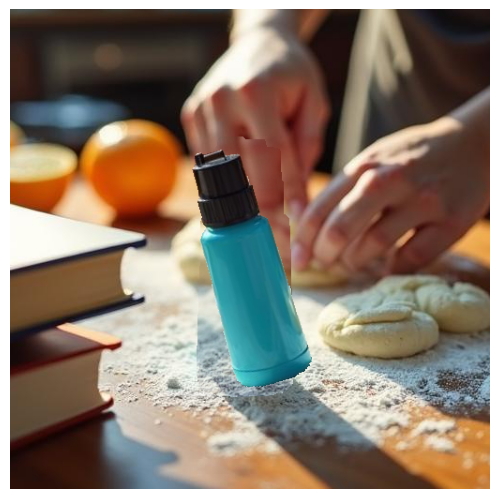

In [5]:

def parse_edit_param(edit_param):
    dx,dy,dz,rx,ry,rz,sx,sy,sz = edit_param
    return [dx, dy, rz, sx, sy]

parsed_edit_param = parse_edit_param(edit_param)
print(f'edit_param: dx:{parsed_edit_param[0]},dy:{parsed_edit_param[1]},rz:{parsed_edit_param[2]},sx:{parsed_edit_param[3]},sy:{parsed_edit_param[4]}')
coarse_input, target_mask, trans_hole_image = re_edit_2d(ori_img, ori_mask, parsed_edit_param, inp_back_ground) 

# temp_view_img(ori_img_3d)
temp_view_img(coarse_input) 
# temp_view(target_mask)
# temp_view_img(trans_hole_image)
# save_img = Image.fromarray(target_mask)
# save_img.save("tgt_mask.png")


/mnt/bn/ocr-doc-nas/zhuhanshen/home/anaconda3/envs/FreeFine/lib/python3.10/site-packages/lightning_fabric/utilities/seed.py:51: 5004969515293064 is not in bounds, numpy accepts from 0 to 4294967295
Seed set to 204610412


current type is tca


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 12.19it/s]


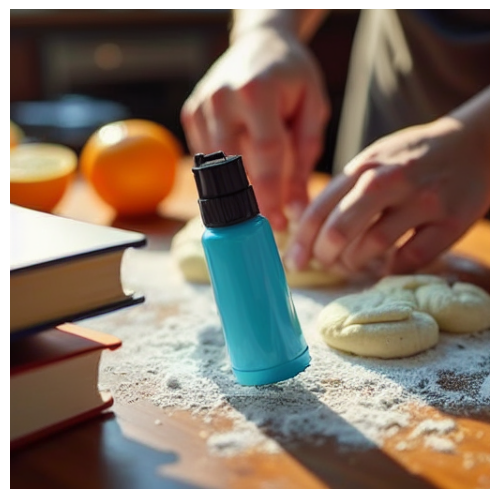

In [7]:
controller = Attention_Modulator(start_layer=10)
model.controller = controller
register_attention_control(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
params = {
            "ori_img": ori_img,
            "ori_mask": ori_mask,
            "coarse_input": coarse_input,
            "target_mask": target_mask,
            "guidance_text": obj_label,
            "guidance_scale": 7.5,
            "eta": 1.0,
            "end_scale": 0.0,
            "end_step": 50,
            "num_step": 50,
            "start_step": 35,
            "seed": seed_r,
            "draw_mask": None,
            "return_intermediates" : False,
            "use_auto_draw" : True,
            "reduce_inp_artifacts" : True,
            "cons_area" : target_mask,
        }

        # 生成结果
generated_results = model.FreeFine_generation(**params)
temp_view_img(generated_results)
# save_img = Image.fromarray(generated_results)
# save_img.save("generated_results.png")
#adjust the start step to get the best result , the earlier the generation ability will be stronger
#here are two groups of params we recommend:
# 1. end_scale=0.5,  start_step=35 #to retain more original details like pose or edge
# 2. end_scale=0.0,  start_step=15 #to boost better generation if you find artifacts 

## Structrual Completion

In [61]:
if edit_type == 'SC':
    # dataset_sc = load_dataset("CIawevy/GeoBench", "sc")['data']
    dataset_sc = load_dataset("/mnt/bn/ocr-doc-nas/zhuhanshen/data/CIawevy/GeoBench", "sc")['data']
    

Generating data split: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 121/121 [00:00<00:00, 340.80 examples/s]


current sample is ID:81


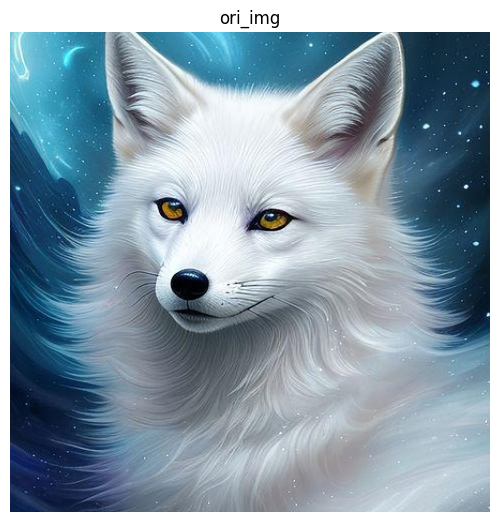

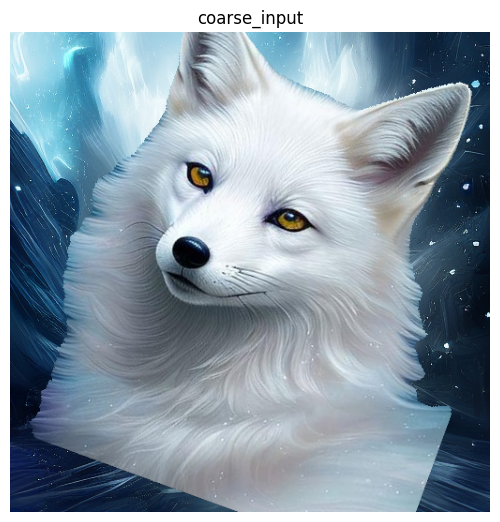

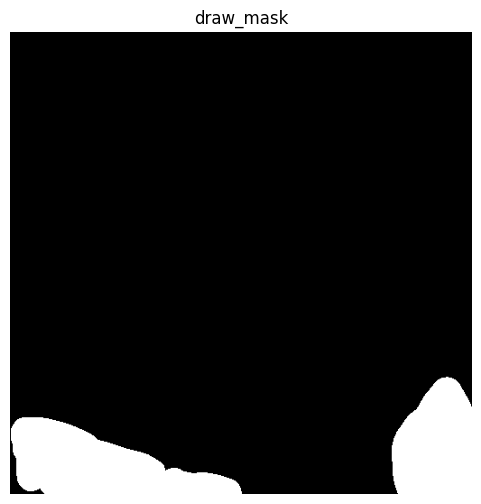

In [81]:
edit_type = 'SC'
if edit_type == 'SC':
    #debug ID=xxx
    id = random.choice(range(len(dataset_sc)))
    print(f'current sample is ID:{id}')
    sample = dataset_sc[id] 
    edit_param = sample['edit_param']
    ori_img = read_and_resize_img_from_pil(sample['ori_img'])
    ori_mask = read_and_resize_mask_from_pil(sample['ori_mask'])
    obj_label = sample['obj_label']
    coarse_input = read_and_resize_img_from_pil(sample['coarse_input'])
    tgt_mask = read_and_resize_mask_from_pil(sample['tgt_mask'])   
    draw_mask = read_and_resize_mask_from_pil(sample['draw_mask'])
    

temp_view_img(ori_img,'ori_img')
temp_view_img(coarse_input,'coarse_input')
temp_view(draw_mask,'draw_mask')


Seed set to 42


prompt:fox
current type is tca


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:09<00:00,  5.19it/s]


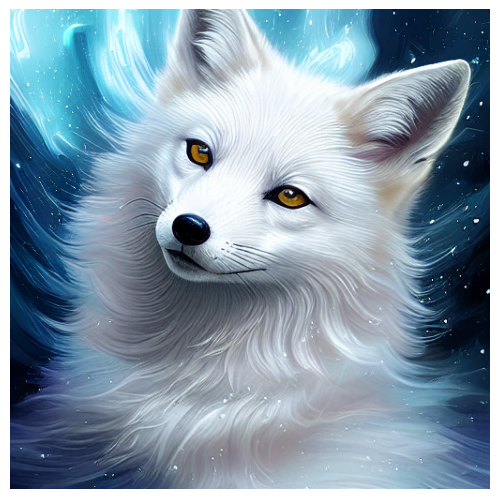

In [82]:
controller = Attention_Modulator(start_layer=10)
model.controller = controller
register_attention_control(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
print(f'prompt:{obj_label}')
params = {
    "ori_img": ori_img,
    "ori_mask": ori_mask,
    "coarse_input": coarse_input,
    "target_mask": tgt_mask,
    "guidance_text": obj_label,
    "guidance_scale": 7.5,
    "eta": 1.0,
    "end_scale": 0.0,
    "end_step": 50,
    "num_step": 50,
    "start_step": 15,
    "seed": 42,
    "draw_mask": draw_mask,
    "return_intermediates" : False,
    "use_auto_draw" : False,
    "reduce_inp_artifacts" : True,
    "cons_area" : tgt_mask,
}

# 生成结果
generated_results = model.FreeFine_generation(**params)
temp_view_img(generated_results)

# 3d Editing (Fast)
- You can directly run the following cell using the pre-generated 3D data. 

In [38]:
edit_type = '3D'
if edit_type == '3D':
    # dataset_3d = load_dataset("CIawevy/GeoBench", "3d")['data'] # If loading fails, download the dataset locally and reload 
    dataset_3d = load_dataset("/mnt/bn/ocr-doc-nas/zhuhanshen/data/CIawevy/GeoBench", "3d")['data']


current sample is ID:153


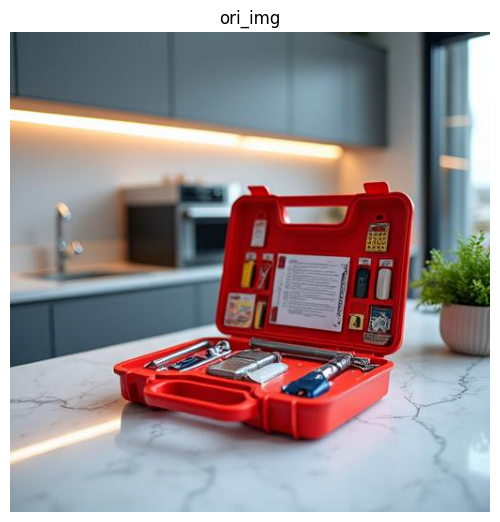

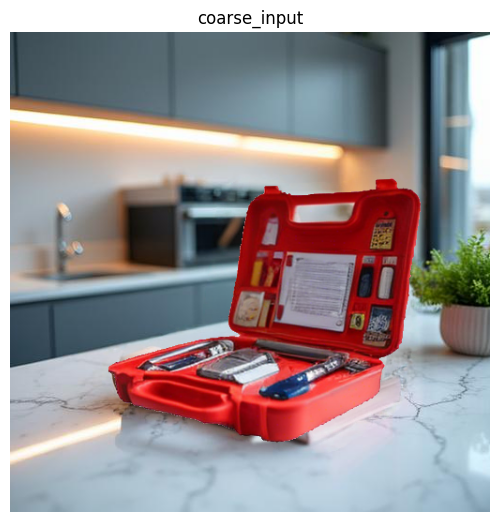

In [46]:
random.seed()
edit_type = '3D'
type_3d ='sv3d'  #switch to ”sv3d“
if edit_type == '3D':
    #debug ID=153
    id = random.choice(range(len(dataset_3d)))
    id = 153
    print(f'current sample is ID:{id}')
    sample = dataset_3d[id] 
    edit_param = sample['edit_param']
    ori_img = read_and_resize_img_from_pil(sample['ori_img'])
    ori_mask = read_and_resize_mask_from_pil(sample['ori_mask'])
    obj_label = sample['obj_label']
    if type_3d == 'sv3d':
        coarse_input = read_and_resize_img_from_pil(sample['coarse_input_1'])
        tgt_mask = read_and_resize_mask_from_pil(sample['target_mask_1'])
        draw_mask = None
    elif type_3d == 'depth':
        coarse_input = read_and_resize_img_from_pil(sample['coarse_input_0'])
        tgt_mask = read_and_resize_mask_from_pil(sample['target_mask_0'])   
        draw_mask = read_and_resize_mask_from_pil(sample['draw_mask'])
    

temp_view_img(ori_img,'ori_img')
temp_view_img(coarse_input,'coarse_input')


Seed set to 42


current type is tca


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.26it/s]


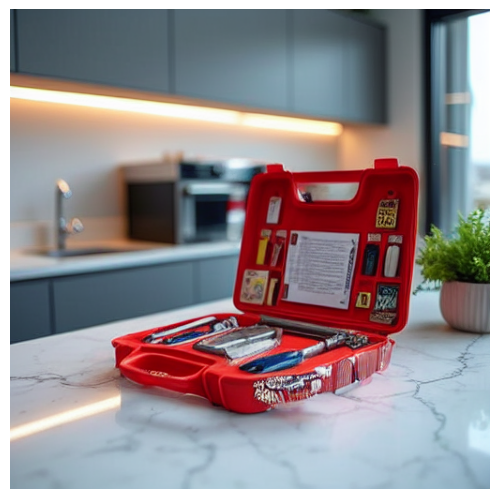

In [58]:
controller = Attention_Modulator(start_layer=10)
model.controller = controller
register_attention_control(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
params = {
    "ori_img": ori_img,
    "ori_mask": ori_mask,
    "coarse_input": coarse_input,
    "target_mask": tgt_mask,
    "guidance_text": obj_label,
    "guidance_scale": 7.5,
    "eta": 1.0,
    "end_scale": 0.0,
    "end_step": 50,
    "num_step": 50,
    "start_step": 25,
    "seed": 42,
    "draw_mask": draw_mask,
    "return_intermediates" : False,
    "use_auto_draw" : False if type_3d=='depth' else True,
    "reduce_inp_artifacts" : True,
    "cons_area" : tgt_mask,
}

# 生成结果
generated_results = model.FreeFine_generation(**params)
temp_view_img(generated_results)

# 3d Editing (full process for DIY data)
- 3D coarse Edit using depth-anything or SV3D
- Background generation
- refine and regeneration

In [4]:
# Using GeoBench as example data 
edit_type = '3D'
if edit_type == '3D':
     # dataset_3d = load_dataset("CIawevy/GeoBench", "3d")['data']
    dataset_3d = load_dataset("/mnt/bn/ocr-doc-nas/zhuhanshen/data/CIawevy/GeoBench", "3d")['data']

current sample is ID:93


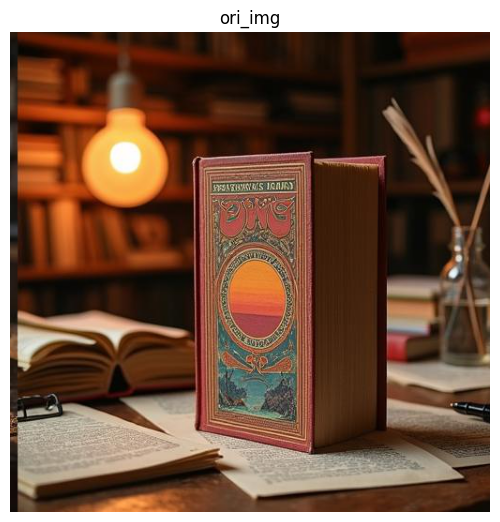

In [5]:
edit_type = '3D'
if edit_type == '3D':
    #debug ID=62
    id = random.choice(range(len(dataset_3d)))
    id = 93 #debug use
    print(f'current sample is ID:{id}')
    sample = dataset_3d[id] 
    edit_param = sample['edit_param']
    ori_img = read_and_resize_img_from_pil(sample['ori_img'])
    ori_mask = read_and_resize_mask_from_pil(sample['ori_mask'])
    obj_label = sample['obj_label']
    #produce yourself
    # if type_3d == 'sv3d': 
    #     coarse_input = read_and_resize_img_from_pil(sample['coarse_input_1'])
    #     tgt_mask = read_and_resize_mask_from_pil(sample['target_mask_1'])
    #     draw_mask = None
    # elif type_3d == 'depth':
    #     coarse_input = read_and_resize_img_from_pil(sample['coarse_input_0'])
    #     tgt_mask = read_and_resize_mask_from_pil(sample['target_mask_0'])   
    #     draw_mask = read_and_resize_mask_from_pil(sample['draw_mask'])
    
temp_view_img(ori_img,'ori_img')
# temp_view_img(coarse_input,'coarse_input')

### Depth-based 3D editing 


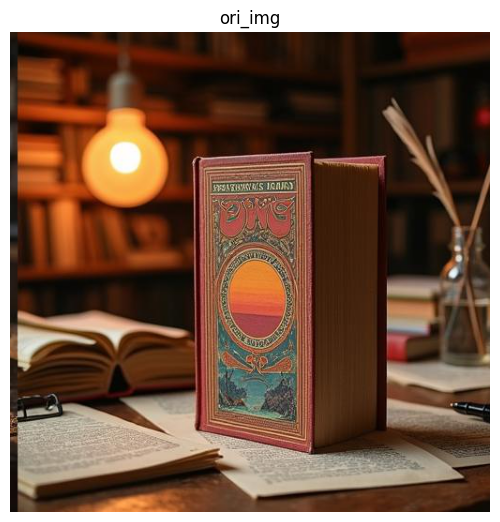

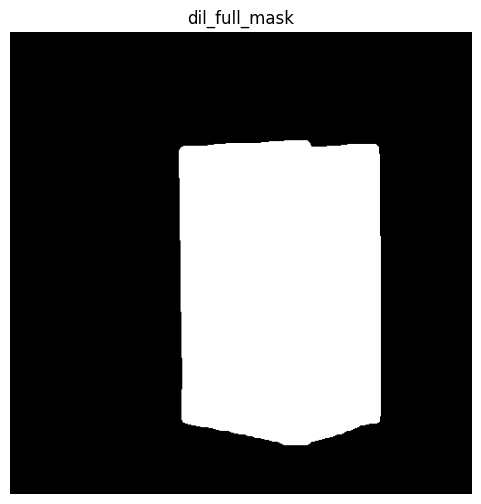

/mnt/bn/ocr-doc-nas/zhuhanshen/home/anaconda3/envs/FreeFine/lib/python3.10/site-packages/lightning_fabric/utilities/seed.py:51: 8720412765354653 is not in bounds, numpy accepts from 0 to 4294967295
Seed set to 564988249


DDIM Sampler: 100%|█████████████████████████████| 50/50 [00:10<00:00,  4.82it/s]


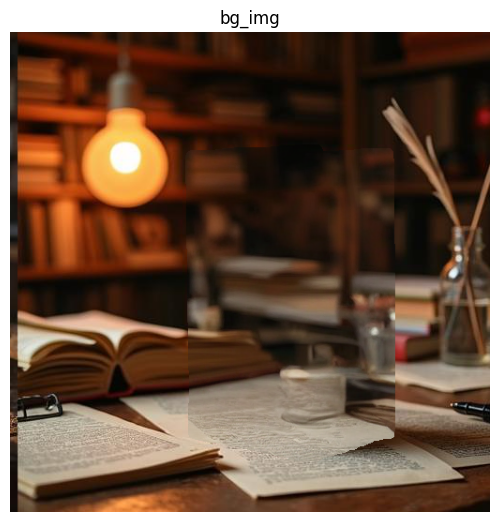

In [38]:
"""
Step1:Background Generation
"""
constrain_areas = get_constrain_areas(mask_list=[ori_mask],ori_mask=ori_mask) #for practice use you can upload mask list with all the object mask to avoid dilation on other objects
dilation_factor = 20
dil_ori_mask = dilate_mask(ori_mask, dilation_factor)
dil_ori_mask = np.where(constrain_areas,0,dil_ori_mask)
temp_view_img(ori_img,'ori_img')
temp_view(dil_ori_mask,'dil_full_mask')

controller = Attention_Modulator()
model.controller = controller
register_attention_control_4bggen(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
# seed_r = 42
generated_results = model.FreeFine_background_generation(ori_img, dil_ori_mask, 'empty scene',
                                                         guidance_scale=3.5,eta=1.0, end_step=50,
                                                         num_step=50, end_scale=0.5,
                                                         start_step=1, share_attn=True, method_type='tca',
                                                         local_text_edit=True,
                                                         local_perturbation=True, verbose=True,
                                                         seed=seed_r,
                                                         return_intermediates=False,latent_blended=False,
                                                         )  


blended = True
if blended:
    #implement fom Brushnet
    mask_blurred = cv2.GaussianBlur(dil_ori_mask, (1, 1), 0) / 255
    mask_np = 1 - (1 - dil_ori_mask) * (1 - mask_blurred)
    image_pasted = ori_img * (1 - mask_np) + generated_results * mask_np
    image_pasted = image_pasted.astype(generated_results.dtype)
    temp_view_img(image_pasted,'bg_img')
    inp_back_ground = image_pasted
else:
    temp_view_img(generated_results,'bg_img')
    # save_img = Image.fromarray(generated_results)
    # save_img.save("FreeFine/jupyter_demo、bg_img.png") #replace with your save path
    inp_back_ground = generated_results


## Pre steps: Following scripts/download_models.sh to download depth-anything model checkpoints or directly use the following commands
- wget https://huggingface.co/spaces/LiheYoung/Depth-Anything/resolve/main/checkpoints/depth_anything_vitl14.pth
- replace the model_path in Line 354 of FreeFine/evaluation/GeoDiffuser/GeoDiffuser/utils/depth_predictor2.py with your own path


edit_param:[0.0, 0.0, 0.0, 0.0, -6.0, 0.0, 1.0, 1.0, 1.0]
Using DEPTH ANYTHING


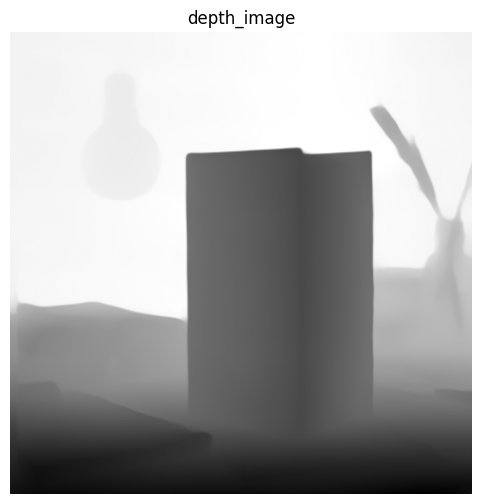

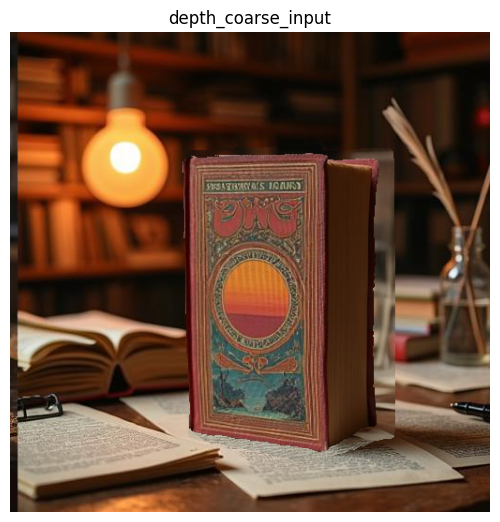

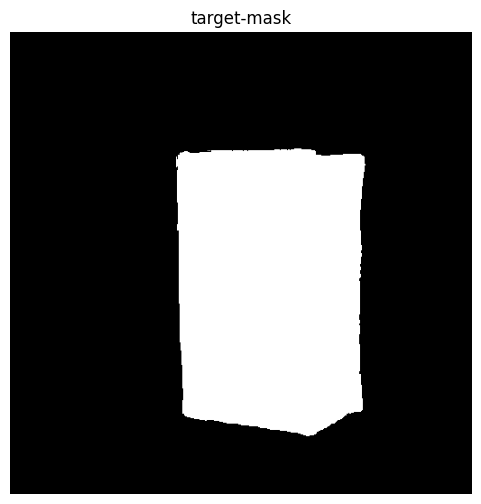

In [36]:
"""
Step2:Depth-based 3D editing(coarse)
"""
## Modified from the Geodiffuser repo, do image resizing and get depth image. You can select the depth model to use, see the get_depth function
LENGTH = 512
from evaluation.GeoDiffuser.GeoDiffuser.utils.ui_utils2 import get_transformed_mask, get_depth
def resize_image_and_get_constant_depth(img):
    original_h, original_w = img.shape[0], img.shape[1]
    input_img = np.array(Image.fromarray(img).resize((LENGTH, LENGTH)))

    depth = np.ones_like(input_img)
    depth_image = np.ones_like(input_img)
    depth, depth_im_vis = get_depth(input_img, "", depth, depth_image, depth_model = "depth_anything") 
    

    return input_img, depth, depth_im_vis, int(original_h), int(original_w)


diy_edit_param = edit_param #replace with your param [dx,dy,dz,rx,ry,rz,sx,sy,sz]
print(f'edit_param:{diy_edit_param}')
 # inp_back_ground = cv2.cvtColor(cv2.imread(osp.join(dst_base,f'inp_img_blended/{image_idx}/{edit_idx}/inp_img.png')),cv2.COLOR_BGR2RGB )  # bgr



input_image, depth_image, depth_image_vis, H_txt, W_txt = resize_image_and_get_constant_depth(ori_img)
if ori_mask.max()<255:
    mask_image = ori_mask * 255
else:
    mask_image = ori_mask

transform_in = np.eye(4)

#transformed_img not used, only for visualization. transform_mat is the transformation matrix used for real editing
transformed_img, mesh_mask,full_mask,point_correspondence = get_transformed_mask(input_image,
                                    mask_image, 
                                    depth_image,
                                    None, # Basically a None when I checked
                                    translation_x=diy_edit_param[0]/LENGTH, 
                                    translation_y=diy_edit_param[1]/LENGTH, 
                                    translation_z=diy_edit_param[2]/LENGTH, 
                                    rotation_x=diy_edit_param[3], 
                                    rotation_y=diy_edit_param[4], 
                                    rotation_z=diy_edit_param[5],
                                    transform_in=transform_in, # See above, basically an identity matrix, it will be modified in this function
                                    splatting_radius = 1.3, 
                                    background_img = inp_back_ground,
                                    scale_x = diy_edit_param[6],
                                    scale_y = diy_edit_param[7],
                                    scale_z = diy_edit_param[8],
                                    splatting_tau = 1.0,
                                    splatting_points_per_pixel = 15,
                                    focal_length = 550)
md_mask = np.where(mesh_mask,0,full_mask)

coarse_input, target_mask, draw_mask = transformed_img.astype(np.uint8), mesh_mask.astype(np.uint8), md_mask.astype(np.uint8)

temp_view(depth_image,'depth_image')

# To further adjust the 2D properties of the 3D results, run the following code
new_edit_param = [0,0,0,1,1] #5 number [dx,dy,rz,sx,sy]
coarse_input, target_mask, trans_hole_image = re_edit_3d(coarse_input, target_mask, new_edit_param, inp_back_ground,ori_img, ori_mask)
temp_view_img(coarse_input,'Adjust-depth-coarse-input') 
temp_view(target_mask,'Adjust-target-mask')


Seed set to 42


current type is tca


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:09<00:00,  5.18it/s]


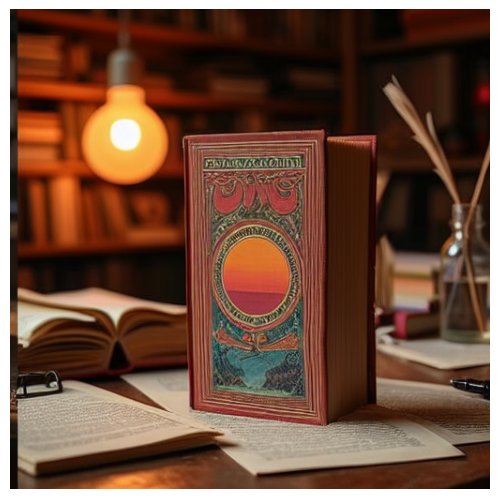

In [34]:
"""
Step3:Refine & Regeneration
"""
controller = Attention_Modulator(start_layer=10)
model.controller = controller
register_attention_control(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
params = {
    "ori_img": ori_img,
    "ori_mask": ori_mask,
    "coarse_input": coarse_input,
    "target_mask": target_mask,
    "guidance_text": obj_label,
    "guidance_scale": 7.5,
    "eta": 1.0,
    "end_scale": 0.0,
    "end_step": 50,
    "num_step": 50,
    "start_step": 15,
    "seed": 42,
    "draw_mask": draw_mask,
    "return_intermediates" : False,
    "use_auto_draw" : False,
    "reduce_inp_artifacts" : True,
    "cons_area" : target_mask,
}

# 生成结果
generated_results = model.FreeFine_generation(**params)
temp_view_img(generated_results)

### SV3D-based 3D editing 


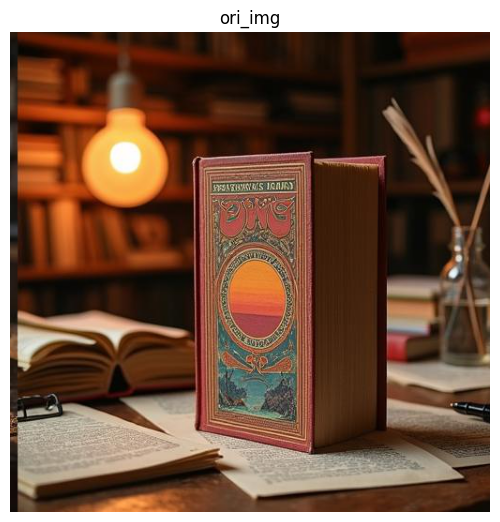

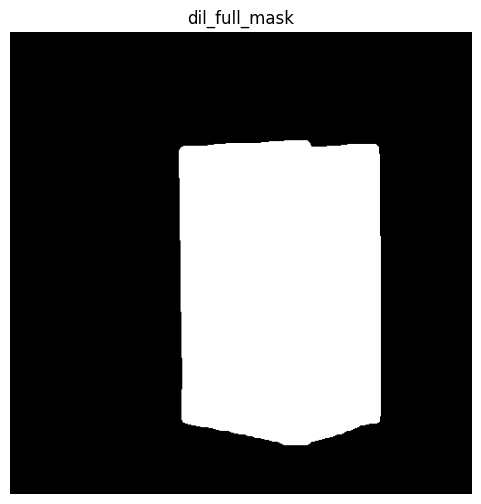

/mnt/bn/ocr-doc-nas/zhuhanshen/home/anaconda3/envs/FreeFine/lib/python3.10/site-packages/lightning_fabric/utilities/seed.py:51: 2668999270597751 is not in bounds, numpy accepts from 0 to 4294967295
Seed set to 4154434175
DDIM Sampler: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:10<00:00,  4.86it/s]


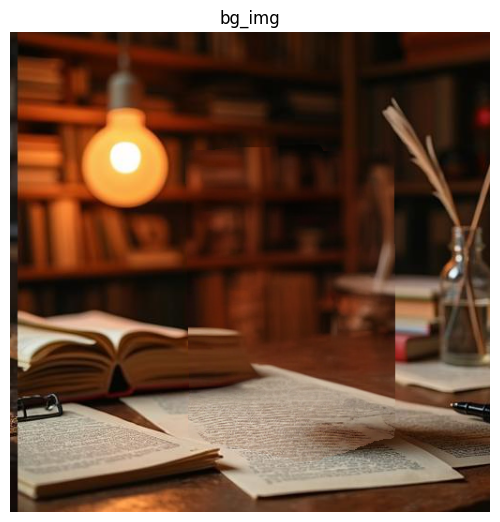

In [7]:
"""
Step1:Background Generation
"""
constrain_areas = get_constrain_areas(mask_list=[ori_mask],ori_mask=ori_mask) #for practice use you can upload mask list with all the object mask to avoid dilation on other objects
dilation_factor = 20
dil_ori_mask = dilate_mask(ori_mask, dilation_factor)
dil_ori_mask = np.where(constrain_areas,0,dil_ori_mask)
temp_view_img(ori_img,'ori_img')
temp_view(dil_ori_mask,'dil_full_mask')

controller = Attention_Modulator()
model.controller = controller
register_attention_control_4bggen(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
# seed_r = 42
generated_results = model.FreeFine_background_generation(ori_img, dil_ori_mask, 'empty scene',
                                                         guidance_scale=3.5,eta=1.0, end_step=50,
                                                         num_step=50, end_scale=0.5,
                                                         start_step=1, share_attn=True, method_type='tca',
                                                         local_text_edit=True,
                                                         local_perturbation=True, verbose=True,
                                                         seed=seed_r,
                                                         return_intermediates=False,latent_blended=False,
                                                         )  


blended = True
if blended:
    #implement fom Brushnet
    mask_blurred = cv2.GaussianBlur(dil_ori_mask, (1, 1), 0) / 255
    mask_np = 1 - (1 - dil_ori_mask) * (1 - mask_blurred)
    image_pasted = ori_img * (1 - mask_np) + generated_results * mask_np
    image_pasted = image_pasted.astype(generated_results.dtype)
    temp_view_img(image_pasted,'bg_img')
    inp_back_ground = image_pasted
else:
    temp_view_img(generated_results,'bg_img')
    # save_img = Image.fromarray(generated_results)
    # save_img.save("FreeFine/jupyter_demo、bg_img.png") #replace with your save path
    inp_back_ground = generated_results






In [54]:
#save imgs and masks for faster offline load 
os.makedirs('vis_demo', exist_ok=True)
Image.fromarray(ori_img).save('vis_demo/ori_img.png')
Image.fromarray(ori_mask).save('vis_demo/ori_mask.png')
Image.fromarray(inp_back_ground).save('vis_demo/bg_img.png')
print(edit_param)


[0.0, 0.0, 0.0, 0.0, -6.0, 0.0, 1.0, 1.0, 1.0]


## Offline SV3D inference(Run the following commands)

```bash
conda activate pt2
cd FreeFine/generative-models/scripts/sampling
python coarse_edit_3d_demo.py # Modify image path & mask path & edit param of your own
```

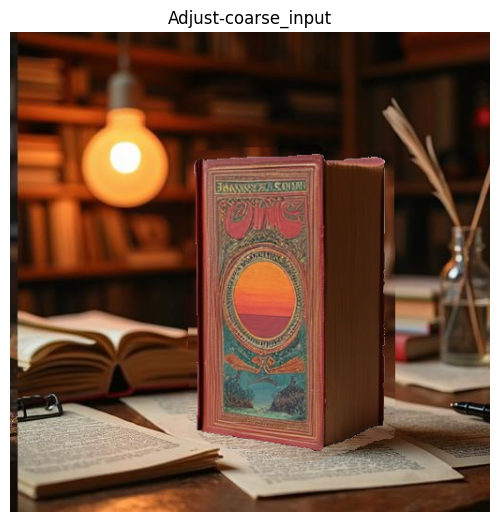

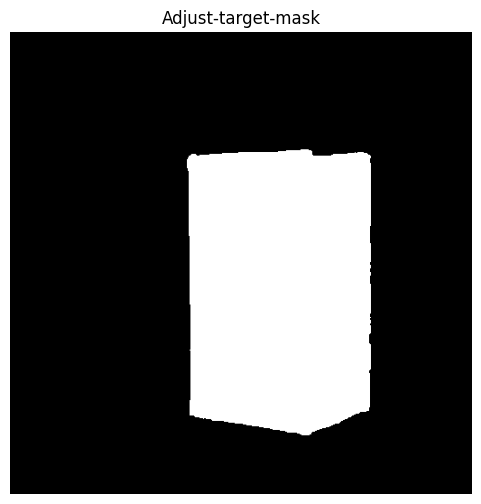

In [8]:
"""
Step2:paste the SV3D coarse Results back to canvas
"""
coarse_input_path = "vis_demo/coarse_input.png" #replace with your own
target_mask_path = "vis_demo/target_mask.png"  #replace with your own
assert os.path.exists(coarse_input_path), 'Make sure you have finish the Offline SV3D inference first '
assert os.path.exists(target_mask_path), 'Make sure you have finish the Offline SV3D inference first '
coarse_input = read_and_resize_img(coarse_input_path)
target_mask = read_and_resize_img(target_mask_path)

# To further adjust the 2D properties of the 3D results, run the following code
new_edit_param = [0,0,0,1,1] #5 number [dx,dy,rz,sx,sy]
coarse_input, target_mask, trans_hole_image = re_edit_3d(coarse_input, target_mask, new_edit_param, inp_back_ground,ori_img, ori_mask)
temp_view_img(coarse_input,'Adjust-coarse_input') 
temp_view(target_mask,'Adjust-target-mask')


Seed set to 42


prompt:book
current type is tca


DDIM Sampler: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:09<00:00,  5.18it/s]


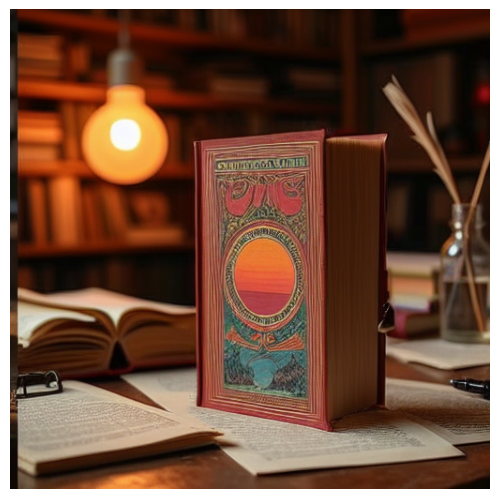

In [10]:
"""
Step3:Refine & Regeneration
"""
controller = Attention_Modulator(start_layer=10)
model.controller = controller
register_attention_control(model, controller)
model.modify_unet_forward()
model.enable_attention_slicing()
model.enable_xformers_memory_efficient_attention()
seed_r = random.randint(0, 10 ** 16)
print(f'prompt:{obj_label}')
params = {
    "ori_img": ori_img,
    "ori_mask": ori_mask,
    "coarse_input": coarse_input,
    "target_mask": target_mask,
    "guidance_text": obj_label,
    "guidance_scale": 7.5,
    "eta": 1.0,
    "end_scale": 0.0,
    "end_step": 50,
    "num_step": 50,
    "start_step": 15,
    "seed": 42,
    "draw_mask": None,
    "return_intermediates" : False,
    "use_auto_draw" : True,
    "reduce_inp_artifacts" : True,
    "cons_area" : target_mask,
}

# 生成结果
generated_results = model.FreeFine_generation(**params)
temp_view_img(generated_results)